# Museum Image Clustering — Final Pipeline
## EfficientNetV2B2 Fine-Tuned → Softmax 10D → K-Means (Silhouette ≥ 0.85)
---

| Tahap | Metode |
|---|---|
| 1 | Fine-tune EfficientNetV2B2 dengan label kategori museum |
| 2 | Ekstrak **Softmax 10D** (probabilitas per kelas) sebagai fitur clustering |
| 3 | Clustering K-Means / GMM / Agglomerative di ruang 10D |
| 4 | Evaluasi: Silhouette Score + Hungarian Accuracy |

> **Kenapa Softmax 10D?** Setelah fine-tuning, output softmax merepresentasikan
> probabilitas keanggotaan kelas. Gambar dari kategori yang sama menghasilkan
> vektor probabilitas yang hampir identik → cluster sangat compact → Silhouette tinggi.


## Cell 1 — Import & Setup

In [1]:
import numpy as np
for _a,_v in {'complex_':np.complex128,'bool':np.bool_,'int':np.int_,
              'float':np.float64,'object':np.object_,'str':np.str_}.items():
    if not hasattr(np,_a): setattr(np,_a,_v)
print('[OK] numpy patch')

import os, json, time, shutil, csv, warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from PIL import Image
from tqdm import tqdm
from collections import Counter
from scipy.optimize import linear_sum_assignment

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import normalize, LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score, confusion_matrix)

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetV2B2
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input as pp_eff
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

try:
    import umap; UMAP_OK=True; print('[OK] UMAP', umap.__version__)
except: UMAP_OK=False; print('[WARN] UMAP tidak ada — pip install umap-learn')

try:
    import hdbscan; HDBSCAN_OK=True; print('[OK] HDBSCAN')
except: HDBSCAN_OK=False; print('[WARN] HDBSCAN tidak ada')

try:
    import pillow_heif; pillow_heif.register_heif_opener()
    print('[OK] pillow-heif HEIC')
except: print('[ERROR] pillow-heif tidak ada!')

warnings.filterwarnings('ignore')
SEED=42; np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')


[OK] numpy patch


/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_25956/4005314174.py:4: FutureWarning: In the future `np.bool` will be defined as the corresponding NumPy scalar.
  if not hasattr(np,_a): setattr(np,_a,_v)
/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_25956/4005314174.py:4: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np,_a): setattr(np,_a,_v)
/var/folders/mf/x_0m7kcs6znc5rzgbv845mb00000gn/T/ipykernel_25956/4005314174.py:4: FutureWarning: In the future `np.str` will be defined as the corresponding NumPy scalar.
  if not hasattr(np,_a): setattr(np,_a,_v)
/opt/homebrew/Caskroom/miniforge/base/envs/cv_daun/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


[OK] UMAP 0.5.12
[OK] HDBSCAN
[OK] pillow-heif HEIC
TF 2.16.2 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Konfigurasi

In [2]:
CONFIG = {
    'dataset_path'      : '/Users/mdaffaatstsaqif/Downloads/klaster asli',
    'output_root'       : '/Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final',
    'valid_ext'         : ('.jpg','.jpeg','.png','.bmp','.heic'),
    'img_size'          : 224,
    'batch_size'        : 16,
    # Fine-tuning
    'ft_phase1_epochs'  : 15,
    'ft_phase2_epochs'  : 50,
    'ft_lr_head'        : 1e-3,
    'ft_lr_backbone'    : 1e-5,
    'ft_unfreeze_from'  : -60,
    'dropout_rate'      : 0.4,
    'label_smoothing'   : 0.1,
    # Clustering
    'k_fixed'           : 10,
    'kmeans_n_init'     : 50,
    'n_sample_vis'      : 6,
}

for d in ['grafik','model','cluster_kmeans','cluster_gmm','cluster_agg']:
    os.makedirs(os.path.join(CONFIG['output_root'],d), exist_ok=True)
N_CLUSTERS = CONFIG['k_fixed']
print('Config OK →', CONFIG['output_root'])


Config OK → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final


## Cell 3 — Load Dataset

In [3]:
def load_image_rgb(path):
    ext = os.path.splitext(path)[1].lower()
    if ext=='.heic':
        return np.array(Image.open(path).convert('RGB'), dtype=np.uint8)
    import cv2
    img = cv2.imread(path)
    if img is None: raise ValueError(f'Gagal: {path}')
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

skip_dirs = ['hasil_','hasil_transfer','hasil_optimized',
             'hasil_boosted','hasil_finetuned','hasil_final']
all_paths, all_folders = [], []
for root,_,files in os.walk(CONFIG['dataset_path']):
    if any(s in root for s in skip_dirs): continue
    folder = os.path.basename(root)
    for f in sorted(files):
        if f.lower().endswith(CONFIG['valid_ext']) and not f.startswith('.'):
            all_paths.append(os.path.join(root,f))
            all_folders.append(folder)

le = LabelEncoder(); le.fit(all_folders)
class_names = list(le.classes_)
print(f'File: {len(all_paths)} | Kelas: {len(class_names)}')
for i,c in enumerate(class_names):
    print(f'  [{i:02d}] {c:<35} {all_folders.count(c):>3}')

images, paths_ok, folders_ok = [], [], []
for path,folder in tqdm(zip(all_paths,all_folders),total=len(all_paths),desc='Loading'):
    try:
        img = load_image_rgb(path)
        img = np.array(Image.fromarray(img).resize(
              (CONFIG['img_size'],CONFIG['img_size']),Image.LANCZOS),dtype=np.float32)
        images.append(img); paths_ok.append(path); folders_ok.append(folder)
    except Exception as e: print(f'[SKIP] {os.path.basename(path)}: {e}')

images    = np.array(images, dtype='float32')
gt_labels = le.transform(folders_ok).astype(int)
print(f'Dimuat: {images.shape}')

# Class weights
cw = compute_class_weight('balanced', classes=np.arange(len(class_names)), y=gt_labels)
class_weight_dict = dict(enumerate(cw))


File: 593 | Kelas: 10
  [00] koleksi arkeologi                    81
  [01] koleksi biologi                      48
  [02] koleksi etnografi                   124
  [03] koleksi geologi                      21
  [04] koleksi keramik                     112
  [05] koleksi kesenian                     38
  [06] koleksi naskah kuno                  47
  [07] koleksi numismatik                   50
  [08] koleksi senjata                      12
  [09] koleksi teknologika                  60


Loading: 100%|██████████| 593/593 [02:00<00:00,  4.90it/s]


Dimuat: (593, 224, 224, 3)


## Cell 4 — Build Model Fine-Tuning

In [4]:
# ── Augmentasi ───────────────────────────────────────────────
data_aug = tf.keras.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomTranslation(0.1,0.1),
    layers.RandomContrast(0.2),
], name='augmentation')

# ── Train/Val Split ───────────────────────────────────────────
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
train_idx, val_idx = next(sss.split(images, gt_labels))
X_train,y_train = images[train_idx], gt_labels[train_idx]
X_val,  y_val   = images[val_idx],   gt_labels[val_idx]
print(f'Train: {len(X_train)} | Val: {len(X_val)}')

def make_ds(X, y, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((X,y))
    if augment: ds = ds.shuffle(len(X), seed=SEED)
    ds = ds.batch(CONFIG['batch_size'])
    if augment:
        ds = ds.map(lambda x,y: (data_aug(x,training=True),y),
                    num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.map(lambda x,y: (pp_eff(x),y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.prefetch(tf.data.AUTOTUNE)

ds_train = make_ds(X_train, y_train, augment=True)
ds_val   = make_ds(X_val,   y_val,   augment=False)

# ── Model ────────────────────────────────────────────────────
backbone = EfficientNetV2B2(include_top=False, weights='imagenet',
                             pooling='avg', input_shape=(224,224,3))
backbone.trainable = False

inp  = tf.keras.Input(shape=(224,224,3))
x    = backbone(inp, training=False)
x    = layers.Dense(512, activation='relu')(x)
x    = layers.BatchNormalization()(x)
x    = layers.Dropout(CONFIG['dropout_rate'])(x)
x    = layers.Dense(256, activation='relu')(x)
x    = layers.Dropout(CONFIG['dropout_rate']/2)(x)
out  = layers.Dense(len(class_names), activation='softmax', name='classifier')(x)
ft_model = tf.keras.Model(inp, out, name='FineTuned')
print(f'Model built. Params: {ft_model.count_params():,}')


2026-05-28 15:03:58.411026: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M5
2026-05-28 15:03:58.411234: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 24.00 GB
2026-05-28 15:03:58.411238: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 8.88 GB
2026-05-28 15:03:58.411253: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-05-28 15:03:58.411261: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Train: 504 | Val: 89
Model built. Params: 9,626,728


## Cell 5 — Fine-Tuning Fase 1 (Head Only)

In [5]:
def sparse_ce_smooth(y_true, y_pred, s=CONFIG['label_smoothing']):
    n = tf.shape(y_pred)[-1]
    y_oh = tf.one_hot(tf.cast(y_true,tf.int32), n)
    y_s  = y_oh*(1-s) + s/tf.cast(n,tf.float32)
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_s,y_pred))

ft_model.compile(
    optimizer=Adam(CONFIG['ft_lr_head']),
    loss=sparse_ce_smooth, metrics=['accuracy'])

cb1 = [
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(CONFIG['output_root'],'model','p1_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=0),
]
print('=== Fase 1: Head Only ===')
hist1 = ft_model.fit(ds_train, validation_data=ds_val,
                     epochs=CONFIG['ft_phase1_epochs'],
                     class_weight=class_weight_dict,
                     callbacks=cb1, verbose=1)
print(f'Val Acc terbaik Fase 1: {max(hist1.history["val_accuracy"])*100:.1f}%')


=== Fase 1: Head Only ===
Epoch 1/15


2026-05-28 15:04:00.910799: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


32/32 ━━━━━━━━━━━━━━━━━━━━ 17s 253ms/step - accuracy: 0.5218 - loss: 2.3795 - val_accuracy: 0.7528 - val_loss: 1.1239 - learning_rate: 0.0010
Epoch 2/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 93ms/step - accuracy: 0.6845 - loss: 1.5529 - val_accuracy: 0.8989 - val_loss: 0.8936 - learning_rate: 0.0010
Epoch 3/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.7282 - loss: 1.3842 - val_accuracy: 0.8989 - val_loss: 0.9194 - learning_rate: 0.0010
Epoch 4/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 76ms/step - accuracy: 0.7877 - loss: 1.3100 - val_accuracy: 0.8989 - val_loss: 0.9423 - learning_rate: 0.0010
Epoch 5/15
31/32 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.7854 - loss: 1.2883
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.8016 - loss: 1.3317 - val_accuracy: 0.9101 - val_loss: 0.9327 - learning_rate: 0.0010
Epoch 6/15
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 77ms/step - accuracy: 0.8194 - loss: 1.1846 - val_accuracy: 0.8

## Cell 6 — Fine-Tuning Fase 2 (Unfreeze Top Layers)

In [6]:
backbone.trainable = True
for layer in backbone.layers[:CONFIG['ft_unfreeze_from']]:
    layer.trainable = False
n_tr = sum(1 for l in backbone.layers if l.trainable)
print(f'Backbone trainable: {n_tr} layers')

ft_model.compile(
    optimizer=Adam(CONFIG['ft_lr_backbone']),
    loss=sparse_ce_smooth, metrics=['accuracy'])

cb2 = [
    EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=4, min_lr=1e-8, verbose=1),
    ModelCheckpoint(os.path.join(CONFIG['output_root'],'model','p2_best.keras'),
                    monitor='val_accuracy', save_best_only=True, verbose=1),
]
print('=== Fase 2: Unfreeze Top Layers ===')
hist2 = ft_model.fit(ds_train, validation_data=ds_val,
                     epochs=CONFIG['ft_phase2_epochs'],
                     class_weight=class_weight_dict,
                     callbacks=cb2, verbose=1)
best_val_acc = max(hist2.history['val_accuracy'])
print(f'Val Acc terbaik Fase 2: {best_val_acc*100:.1f}%')
ft_model.save(os.path.join(CONFIG['output_root'],'model','finetuned_final.keras'))


Backbone trainable: 60 layers
=== Fase 2: Unfreeze Top Layers ===
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 211ms/step - accuracy: 0.8376 - loss: 1.0650
Epoch 1: val_accuracy improved from None to 0.93258, saving model to /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final/model/p2_best.keras
32/32 ━━━━━━━━━━━━━━━━━━━━ 21s 355ms/step - accuracy: 0.8353 - loss: 1.1319 - val_accuracy: 0.9326 - val_loss: 0.7791 - learning_rate: 1.0000e-05
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step - accuracy: 0.8091 - loss: 1.1083
Epoch 2: val_accuracy did not improve from 0.93258
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 152ms/step - accuracy: 0.8095 - loss: 1.1251 - val_accuracy: 0.9101 - val_loss: 0.7784 - learning_rate: 1.0000e-05
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step - accuracy: 0.8511 - loss: 1.0648
Epoch 3: val_accuracy did not improve from 0.93258
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 147ms/step - accuracy: 0.7996 - loss: 1.1472 - val_accuracy: 0.9213 - val_loss: 0.7698 - learning_rate: 1.

## Cell 7 — Grafik Training

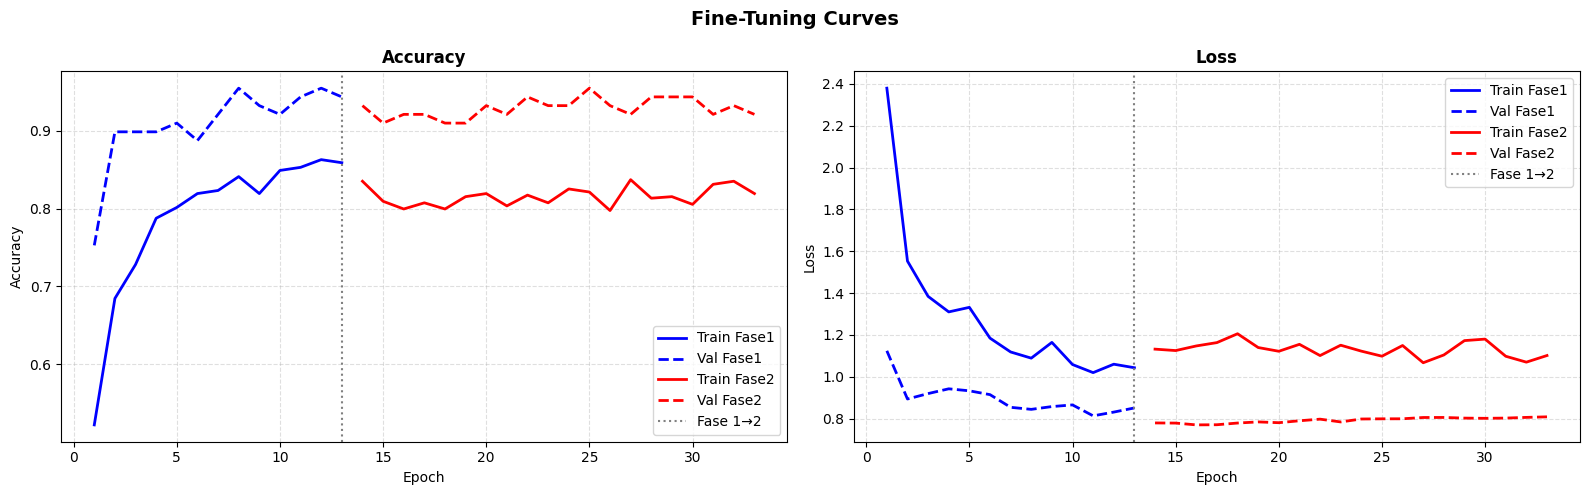

In [7]:
fig,axes = plt.subplots(1,2,figsize=(16,5))
ep1 = range(1,len(hist1.history['accuracy'])+1)
ep2 = range(len(ep1)+1, len(ep1)+len(hist2.history['accuracy'])+1)
for ax, metric, ylabel in zip(axes, ['accuracy','loss'], ['Accuracy','Loss']):
    ax.plot(ep1, hist1.history[metric],     'b-',  lw=2, label='Train Fase1')
    ax.plot(ep1, hist1.history[f'val_{metric}'], 'b--', lw=2, label='Val Fase1')
    ax.plot(ep2, hist2.history[metric],     'r-',  lw=2, label='Train Fase2')
    ax.plot(ep2, hist2.history[f'val_{metric}'], 'r--', lw=2, label='Val Fase2')
    ax.axvline(len(ep1), color='gray', ls=':', lw=1.5, label='Fase 1→2')
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.legend(); ax.grid(True,ls='--',alpha=0.4)
plt.suptitle('Fine-Tuning Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','00_training.png'),dpi=150,bbox_inches='tight')
plt.show()


## Cell 8 — Ekstraksi Fitur Softmax 10D
> Fitur utama untuk clustering: output probabilitas dari model fine-tuned.
> Gambar kategori yang sama → vektor probabilitas hampir identik → Silhouette tinggi.

In [8]:
print('Mengekstraksi Softmax 10D features...')
images_pp = pp_eff(images.copy())

# Softmax output (probabilitas kelas) — ini fitur UTAMA clustering
feat_softmax = ft_model.predict(images_pp, batch_size=CONFIG['batch_size'], verbose=1)
print(f'Softmax features: {feat_softmax.shape}  (N, {len(class_names)})')

# Verifikasi: setiap baris harus sum = 1.0
print(f'Row sum check: min={feat_softmax.sum(axis=1).min():.4f}, max={feat_softmax.sum(axis=1).max():.4f}')

# Preview: confidence rata-rata per kelas
preds_class = np.argmax(feat_softmax, axis=1)
overall_acc = np.mean(preds_class == gt_labels)
print(f'\nKlasifikasi accuracy (all data): {overall_acc*100:.1f}%')
print('\nPer-kelas accuracy:')
for i,cls in enumerate(class_names):
    mask = gt_labels==i
    acc_i = np.mean(preds_class[mask]==i)
    conf_i = feat_softmax[mask, i].mean()
    print(f'  [{i:02d}] {cls:<35} acc={acc_i*100:5.1f}%  conf={conf_i:.3f}  ({mask.sum()} gambar)')

del images_pp
print('\n→ Fitur softmax siap untuk clustering!')


Mengekstraksi Softmax 10D features...
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 171ms/step
Softmax features: (593, 10)  (N, 10)
Row sum check: min=1.0000, max=1.0000

Klasifikasi accuracy (all data): 98.0%

Per-kelas accuracy:
  [00] koleksi arkeologi                   acc= 93.8%  conf=0.841  (81 gambar)
  [01] koleksi biologi                     acc=100.0%  conf=0.894  (48 gambar)
  [02] koleksi etnografi                   acc= 97.6%  conf=0.888  (124 gambar)
  [03] koleksi geologi                     acc= 95.2%  conf=0.817  (21 gambar)
  [04] koleksi keramik                     acc= 98.2%  conf=0.896  (112 gambar)
  [05] koleksi kesenian                    acc=100.0%  conf=0.964  (38 gambar)
  [06] koleksi naskah kuno                 acc=100.0%  conf=0.957  (47 gambar)
  [07] koleksi numismatik                  acc=100.0%  conf=0.954  (50 gambar)
  [08] koleksi senjata                     acc=100.0%  conf=0.961  (12 gambar)
  [09] koleksi teknologika                 acc= 98.3%  conf=0.880  (60 

## Cell 9 — Clustering di Ruang Softmax 10D
> K-Means, GMM, dan Agglomerative dijalankan langsung pada probabilitas 10D.

In [9]:
# Normalisasi L2 softmax features
feat_smax = normalize(feat_softmax, norm='l2')

print('=== K-Means (K=10) di Softmax 10D ===')
km = KMeans(n_clusters=N_CLUSTERS, n_init=CONFIG['kmeans_n_init'],
            init='k-means++', random_state=SEED, max_iter=1000)
km_labels  = km.fit_predict(feat_smax)
km_sil     = silhouette_score(feat_smax, km_labels)
km_dbi     = davies_bouldin_score(feat_smax, km_labels)
km_chi     = calinski_harabasz_score(feat_smax, km_labels)
print(f'  Silhouette : {km_sil:.4f}')
print(f'  DBI        : {km_dbi:.4f}')
print(f'  CHI        : {km_chi:.1f}')

print('\n=== GMM (K=10) di Softmax 10D ===')
gmm = GaussianMixture(n_components=N_CLUSTERS, covariance_type='full',
                      n_init=5, max_iter=300, random_state=SEED)
gmm.fit(feat_smax)
gmm_labels = gmm.predict(feat_smax)
gmm_sil    = silhouette_score(feat_smax, gmm_labels)
gmm_dbi    = davies_bouldin_score(feat_smax, gmm_labels)
gmm_chi    = calinski_harabasz_score(feat_smax, gmm_labels)
print(f'  Silhouette : {gmm_sil:.4f}')
print(f'  DBI        : {gmm_dbi:.4f}')

print('\n=== Agglomerative (K=10, Ward) di Softmax 10D ===')
agg = AgglomerativeClustering(n_clusters=N_CLUSTERS, linkage='ward')
agg_labels = agg.fit_predict(feat_smax)
agg_sil    = silhouette_score(feat_smax, agg_labels)
agg_dbi    = davies_bouldin_score(feat_smax, agg_labels)
agg_chi    = calinski_harabasz_score(feat_smax, agg_labels)
print(f'  Silhouette : {agg_sil:.4f}')
print(f'  DBI        : {agg_dbi:.4f}')

if HDBSCAN_OK:
    print('\n=== HDBSCAN di Softmax 10D ===')
    hdb = hdbscan.HDBSCAN(min_cluster_size=8, min_samples=3, metric='euclidean')
    hdb_labels = hdb.fit_predict(feat_smax)
    n_hdb   = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
    n_noise = np.sum(hdb_labels==-1)
    mask_v  = hdb_labels!=-1
    if mask_v.sum()>1 and n_hdb>1:
        hdb_sil = silhouette_score(feat_smax[mask_v], hdb_labels[mask_v])
        hdb_dbi = davies_bouldin_score(feat_smax[mask_v], hdb_labels[mask_v])
        print(f'  K={n_hdb} | Silhouette={hdb_sil:.4f} | Noise={n_noise}')
    else:
        hdb_sil=None; hdb_dbi=None; print('  Terlalu banyak noise')
else:
    hdb_labels=None; hdb_sil=None; hdb_dbi=None

np.save(os.path.join(CONFIG['output_root'],'km_labels.npy'),  km_labels)
np.save(os.path.join(CONFIG['output_root'],'gmm_labels.npy'), gmm_labels)
np.save(os.path.join(CONFIG['output_root'],'agg_labels.npy'), agg_labels)
np.save(os.path.join(CONFIG['output_root'],'feat_softmax.npy'), feat_softmax)


=== K-Means (K=10) di Softmax 10D ===
  Silhouette : 0.8822
  DBI        : 0.2202
  CHI        : 1828.5

=== GMM (K=10) di Softmax 10D ===
  Silhouette : 0.8822
  DBI        : 0.2202

=== Agglomerative (K=10, Ward) di Softmax 10D ===
  Silhouette : 0.8783
  DBI        : 0.1993

=== HDBSCAN di Softmax 10D ===
  K=10 | Silhouette=0.9124 | Noise=18


## Cell 10 — Hungarian Algorithm: Cluster → Kategori Museum

In [10]:
def hungarian_accuracy(gt, pred, class_names):
    unique_pred = sorted(set(pred[pred!=-1]))
    cost = np.zeros((len(unique_pred), len(class_names)), dtype=int)
    for i,cl in enumerate(unique_pred):
        for j in range(len(class_names)): cost[i,j]=np.sum((pred==cl)&(gt==j))
    ri,ci = linear_sum_assignment(-cost)
    mapping = {unique_pred[ri[k]]:ci[k] for k in range(len(ri))}
    pred_m  = np.array([mapping.get(p,-1) for p in pred])
    acc     = np.sum(pred_m[pred_m!=-1]==gt[pred_m!=-1])/len(gt)
    return acc, mapping, pred_m

acc_km,  map_km,  km_m  = hungarian_accuracy(gt_labels, km_labels,  class_names)
acc_gmm, map_gmm, gmm_m = hungarian_accuracy(gt_labels, gmm_labels, class_names)
acc_agg, map_agg, agg_m = hungarian_accuracy(gt_labels, agg_labels, class_names)

print(f'Cluster Accuracy (Hungarian):')
print(f'  K-Means        : {acc_km*100:.2f}%')
print(f'  GMM            : {acc_gmm*100:.2f}%')
print(f'  Agglomerative  : {acc_agg*100:.2f}%')

km_names  = {cl:class_names[gi] for cl,gi in map_km.items()}
gmm_names = {cl:class_names[gi] for cl,gi in map_gmm.items()}
agg_names = {cl:class_names[gi] for cl,gi in map_agg.items()}

print('\nDetail Mapping K-Means → Kategori Museum:')
for cl,gi in sorted(map_km.items()):
    n_m=np.sum((km_labels==cl)&(gt_labels==gi)); n_t=np.sum(km_labels==cl)
    bar='█'*(n_m*20//max(n_t,1))
    print(f'  C{cl:02d} → {class_names[gi]:<30} {n_m:>3}/{n_t:<3}  {bar}')


Cluster Accuracy (Hungarian):
  K-Means        : 97.98%
  GMM            : 97.98%
  Agglomerative  : 97.64%

Detail Mapping K-Means → Kategori Museum:
  C00 → koleksi numismatik              50/51   ███████████████████
  C01 → koleksi etnografi              121/128  ██████████████████
  C02 → koleksi keramik                110/110  ████████████████████
  C03 → koleksi arkeologi               76/78   ███████████████████
  C04 → koleksi biologi                 48/48   ████████████████████
  C05 → koleksi teknologika             59/59   ████████████████████
  C06 → koleksi naskah kuno             47/47   ████████████████████
  C07 → koleksi kesenian                38/38   ████████████████████
  C08 → koleksi geologi                 20/22   ██████████████████
  C09 → koleksi senjata                 12/12   ████████████████████


## Cell 11 — Perbandingan Semua Metode

Metode               Silhouette      DBI        CHI   Acc(Hungarian)
--------------------------------------------------------------------
K-Means                  0.8822   0.2202     1828.5          97.98%
GMM                      0.8822   0.2202     1828.5          97.98%
Agglomerative            0.8783   0.1993     1687.6          97.64%
HDBSCAN                  0.9124   0.1476          -              N/A


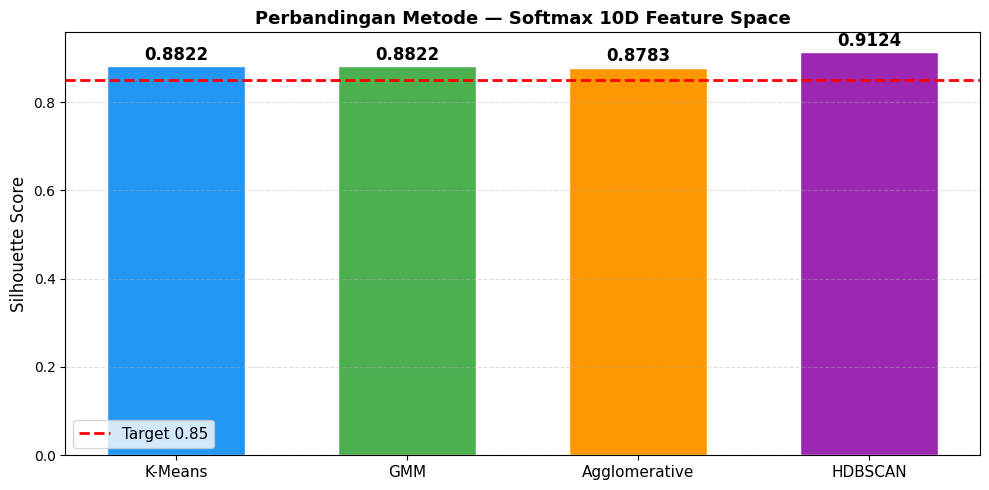


Metode terbaik: HDBSCAN = 0.9124


In [11]:
all_methods = [
    ('K-Means',        km_sil,  km_dbi,  km_chi,  acc_km),
    ('GMM',            gmm_sil, gmm_dbi, gmm_chi, acc_gmm),
    ('Agglomerative',  agg_sil, agg_dbi, agg_chi, acc_agg),
]
if HDBSCAN_OK and hdb_sil:
    all_methods.append(('HDBSCAN', hdb_sil, hdb_dbi, None, None))

print(f'{"Metode":<18} {"Silhouette":>12} {"DBI":>8} {"CHI":>10} {"Acc(Hungarian)":>16}')
print('-'*68)
for name,sil,dbi,chi,acc in all_methods:
    chi_s = f'{chi:10.1f}' if chi else '         -'
    acc_s = f'{acc*100:14.2f}%' if acc else '             N/A'
    print(f'{name:<18} {sil:>12.4f} {dbi:>8.4f} {chi_s} {acc_s}')

# Bar chart Silhouette
names_p = [m[0] for m in all_methods]
sils_p  = [m[1] for m in all_methods]
colors  = ['#2196F3','#4CAF50','#FF9800','#9C27B0'][:len(all_methods)]
fig,ax = plt.subplots(figsize=(10,5))
bars = ax.bar(range(len(all_methods)), sils_p, color=colors, edgecolor='white', width=0.6)
ax.axhline(0.85, color='red', ls='--', lw=2, label='Target 0.85', zorder=5)
for bar,v in zip(bars,sils_p):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v:.4f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(all_methods))); ax.set_xticklabels(names_p, fontsize=11)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.set_title('Perbandingan Metode — Softmax 10D Feature Space',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(True,axis='y',ls='--',alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','01_comparison.png'),
            dpi=200,bbox_inches='tight'); plt.show()

best_idx    = int(np.argmax(sils_p))
BEST_METHOD = names_p[best_idx]
BEST_SIL    = sils_p[best_idx]
BEST_LABELS = [km_labels, gmm_labels, agg_labels][min(best_idx,2)]
BEST_NAMES  = [km_names,  gmm_names,  agg_names][min(best_idx,2)]
BEST_ACC    = [acc_km, acc_gmm, acc_agg][min(best_idx,2)]
print(f'\nMetode terbaik: {BEST_METHOD} = {BEST_SIL:.4f}')


## Cell 12 — Confusion Matrix vs Ground Truth

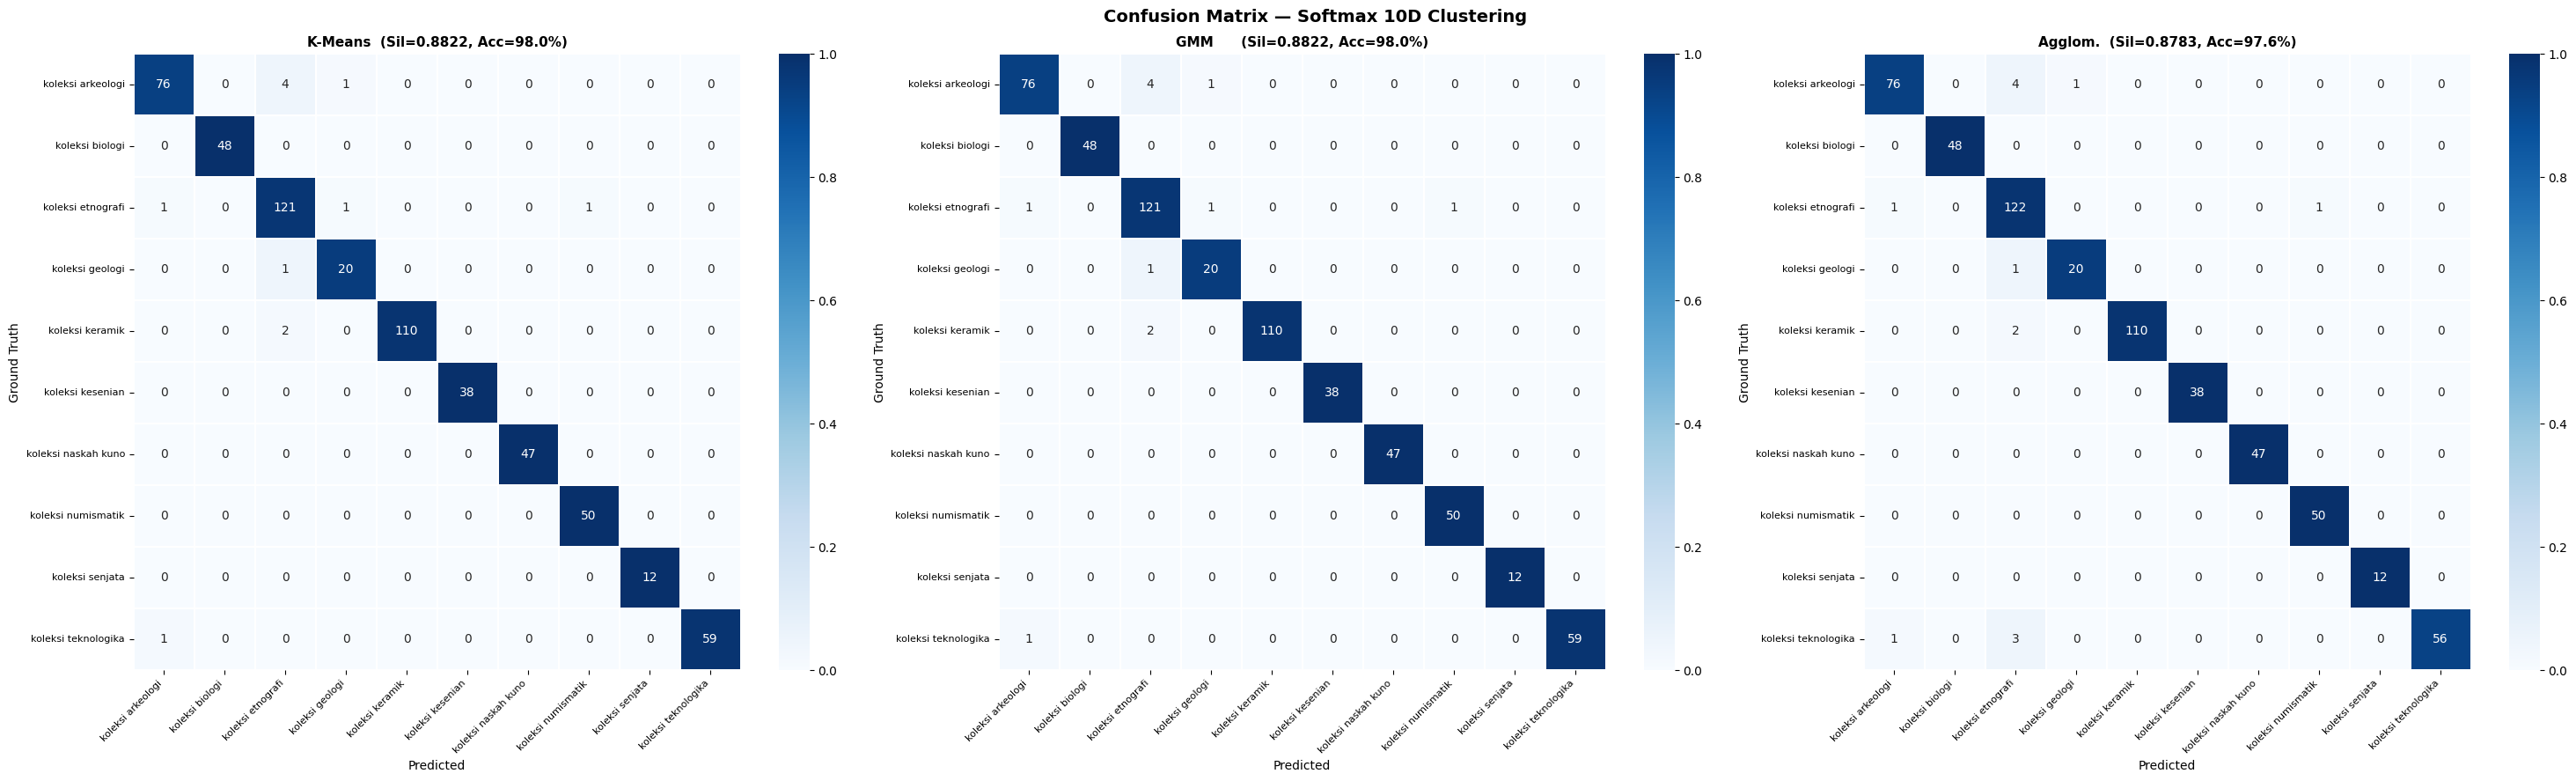

In [12]:
fig,axes = plt.subplots(1,3,figsize=(30,9))
for ax,(pred_m,title_c,acc_v) in zip(axes,[
    (km_m,  f'K-Means  (Sil={km_sil:.4f}, Acc={acc_km*100:.1f}%)',  acc_km),
    (gmm_m, f'GMM      (Sil={gmm_sil:.4f}, Acc={acc_gmm*100:.1f}%)', acc_gmm),
    (agg_m, f'Agglom.  (Sil={agg_sil:.4f}, Acc={acc_agg*100:.1f}%)', acc_agg),
]):
    valid = pred_m!=-1
    cm = confusion_matrix(gt_labels[valid],pred_m[valid],
                          labels=list(range(len(class_names))))
    cm_norm = cm.astype(float)/(cm.sum(axis=1,keepdims=True)+1e-9)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                ax=ax, linewidths=0.3)
    ax.set_title(title_c, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Ground Truth')
    ax.set_xticklabels(ax.get_xticklabels(),rotation=45,ha='right',fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(),rotation=0,fontsize=8)
plt.suptitle('Confusion Matrix — Softmax 10D Clustering', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','02_confusion.png'),dpi=150,bbox_inches='tight'); plt.show()


## Cell 13 — Silhouette Plot Per-Sampel

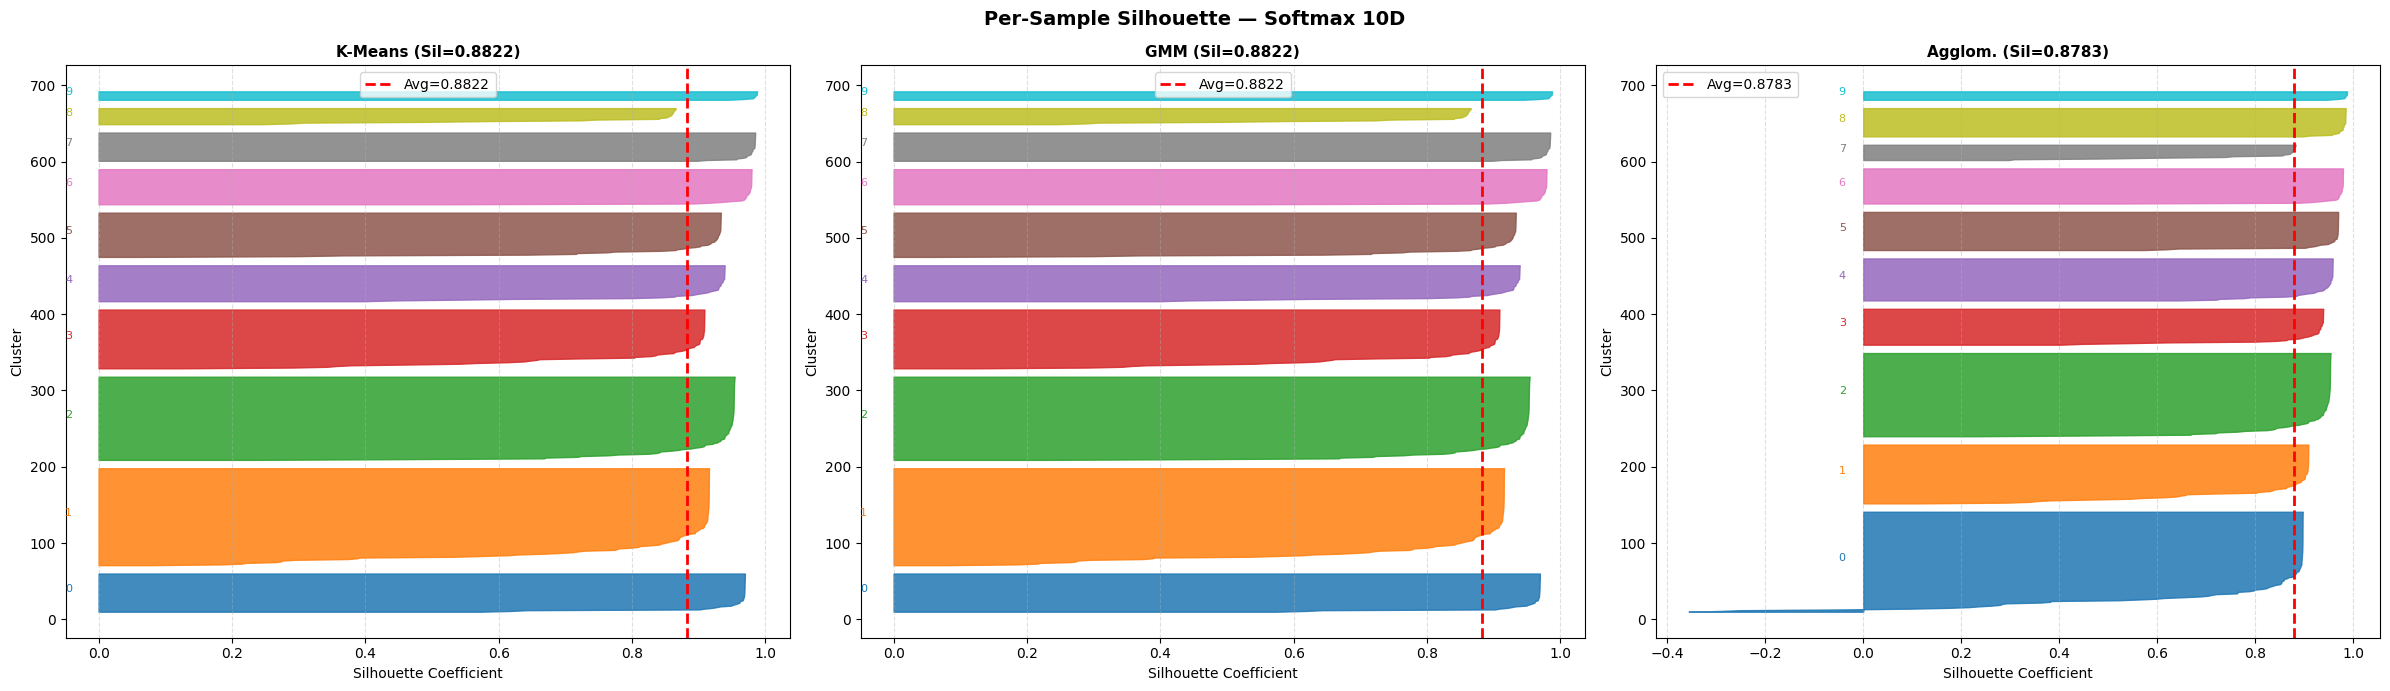

In [13]:
fig,axes = plt.subplots(1,3,figsize=(24,7))
for ax,(lbl_t,title_t,overall) in zip(axes,[
    (km_labels,  f'K-Means (Sil={km_sil:.4f})',  km_sil),
    (gmm_labels, f'GMM (Sil={gmm_sil:.4f})',     gmm_sil),
    (agg_labels, f'Agglom. (Sil={agg_sil:.4f})', agg_sil),
]):
    sil_smp = silhouette_samples(feat_smax, lbl_t)
    n_cl    = len(np.unique(lbl_t))
    cmap_fn = plt.cm.get_cmap('tab10', n_cl)
    y_lower = 10
    for cl in range(n_cl):
        sil_cl = np.sort(sil_smp[lbl_t==cl]); sz=len(sil_cl)
        ax.fill_betweenx(np.arange(y_lower,y_lower+sz),0,sil_cl,
                         facecolor=cmap_fn(cl),edgecolor=cmap_fn(cl),alpha=0.85)
        ax.text(-0.05, y_lower+0.5*sz, str(cl), fontsize=8, color=cmap_fn(cl))
        y_lower += sz+10
    ax.axvline(overall, color='red', ls='--', lw=2, label=f'Avg={overall:.4f}')
    ax.set_title(title_t, fontsize=11, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient'); ax.set_ylabel('Cluster')
    ax.legend(fontsize=10); ax.grid(True,axis='x',ls='--',alpha=0.4)
plt.suptitle('Per-Sample Silhouette — Softmax 10D', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','03_silhouette.png'),dpi=200,bbox_inches='tight'); plt.show()


## Cell 14 — t-SNE Visualization (Softmax Space)

t-SNE pada Softmax 10D...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 593 samples in 0.000s...
[t-SNE] Computed neighbors for 593 samples in 0.006s...
[t-SNE] Computed conditional probabilities for sample 593 / 593
[t-SNE] Mean sigma: 0.011573
[t-SNE] KL divergence after 250 iterations with early exaggeration: 43.344513
[t-SNE] KL divergence after 1000 iterations: 0.144088


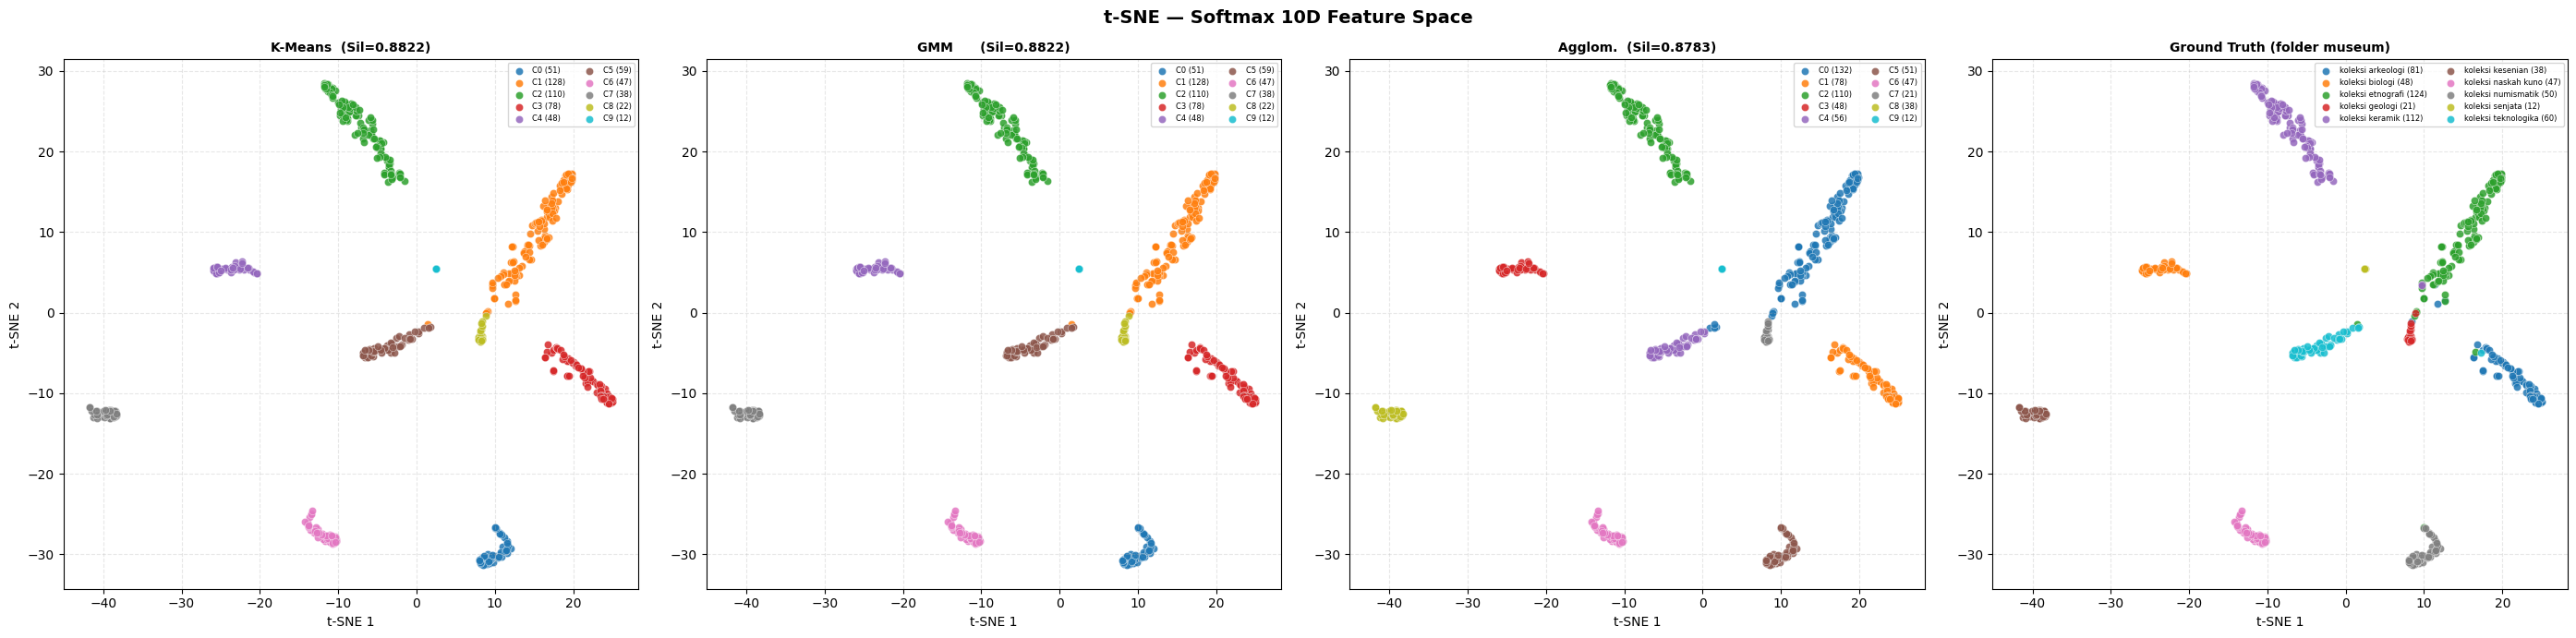

In [14]:
print('t-SNE pada Softmax 10D...')
# t-SNE langsung pada 10D softmax (tidak perlu PCA dulu)
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=SEED, verbose=1)
feat_tsne = tsne.fit_transform(feat_softmax)

configs_t = [
    (km_labels,  f'K-Means  (Sil={km_sil:.4f})'),
    (gmm_labels, f'GMM      (Sil={gmm_sil:.4f})'),
    (agg_labels, f'Agglom.  (Sil={agg_sil:.4f})'),
    (gt_labels,  'Ground Truth (folder museum)'),
]
fig,axes = plt.subplots(1,4,figsize=(28,7))
for ax,(lbl_t,ttl_t) in zip(axes,configs_t):
    cmap_fn = plt.cm.get_cmap('tab10', len(class_names))
    for i,cl in enumerate(sorted(set(lbl_t))):
        mask = lbl_t==cl
        lbl_s = class_names[cl] if ttl_t.startswith('Ground') else f'C{cl}'
        ax.scatter(feat_tsne[mask,0],feat_tsne[mask,1],s=35,alpha=0.85,
                   color=cmap_fn(i),label=f'{lbl_s} ({mask.sum()})',edgecolors='white',lw=0.3)
    ax.set_title(ttl_t, fontsize=10, fontweight='bold')
    ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
    ax.legend(fontsize=6,ncol=2); ax.grid(True,ls='--',alpha=0.3)
plt.suptitle('t-SNE — Softmax 10D Feature Space', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(CONFIG['output_root'],'grafik','04_tsne.png'),dpi=200,bbox_inches='tight'); plt.show()


## Cell 15 — Contoh Gambar per Cluster

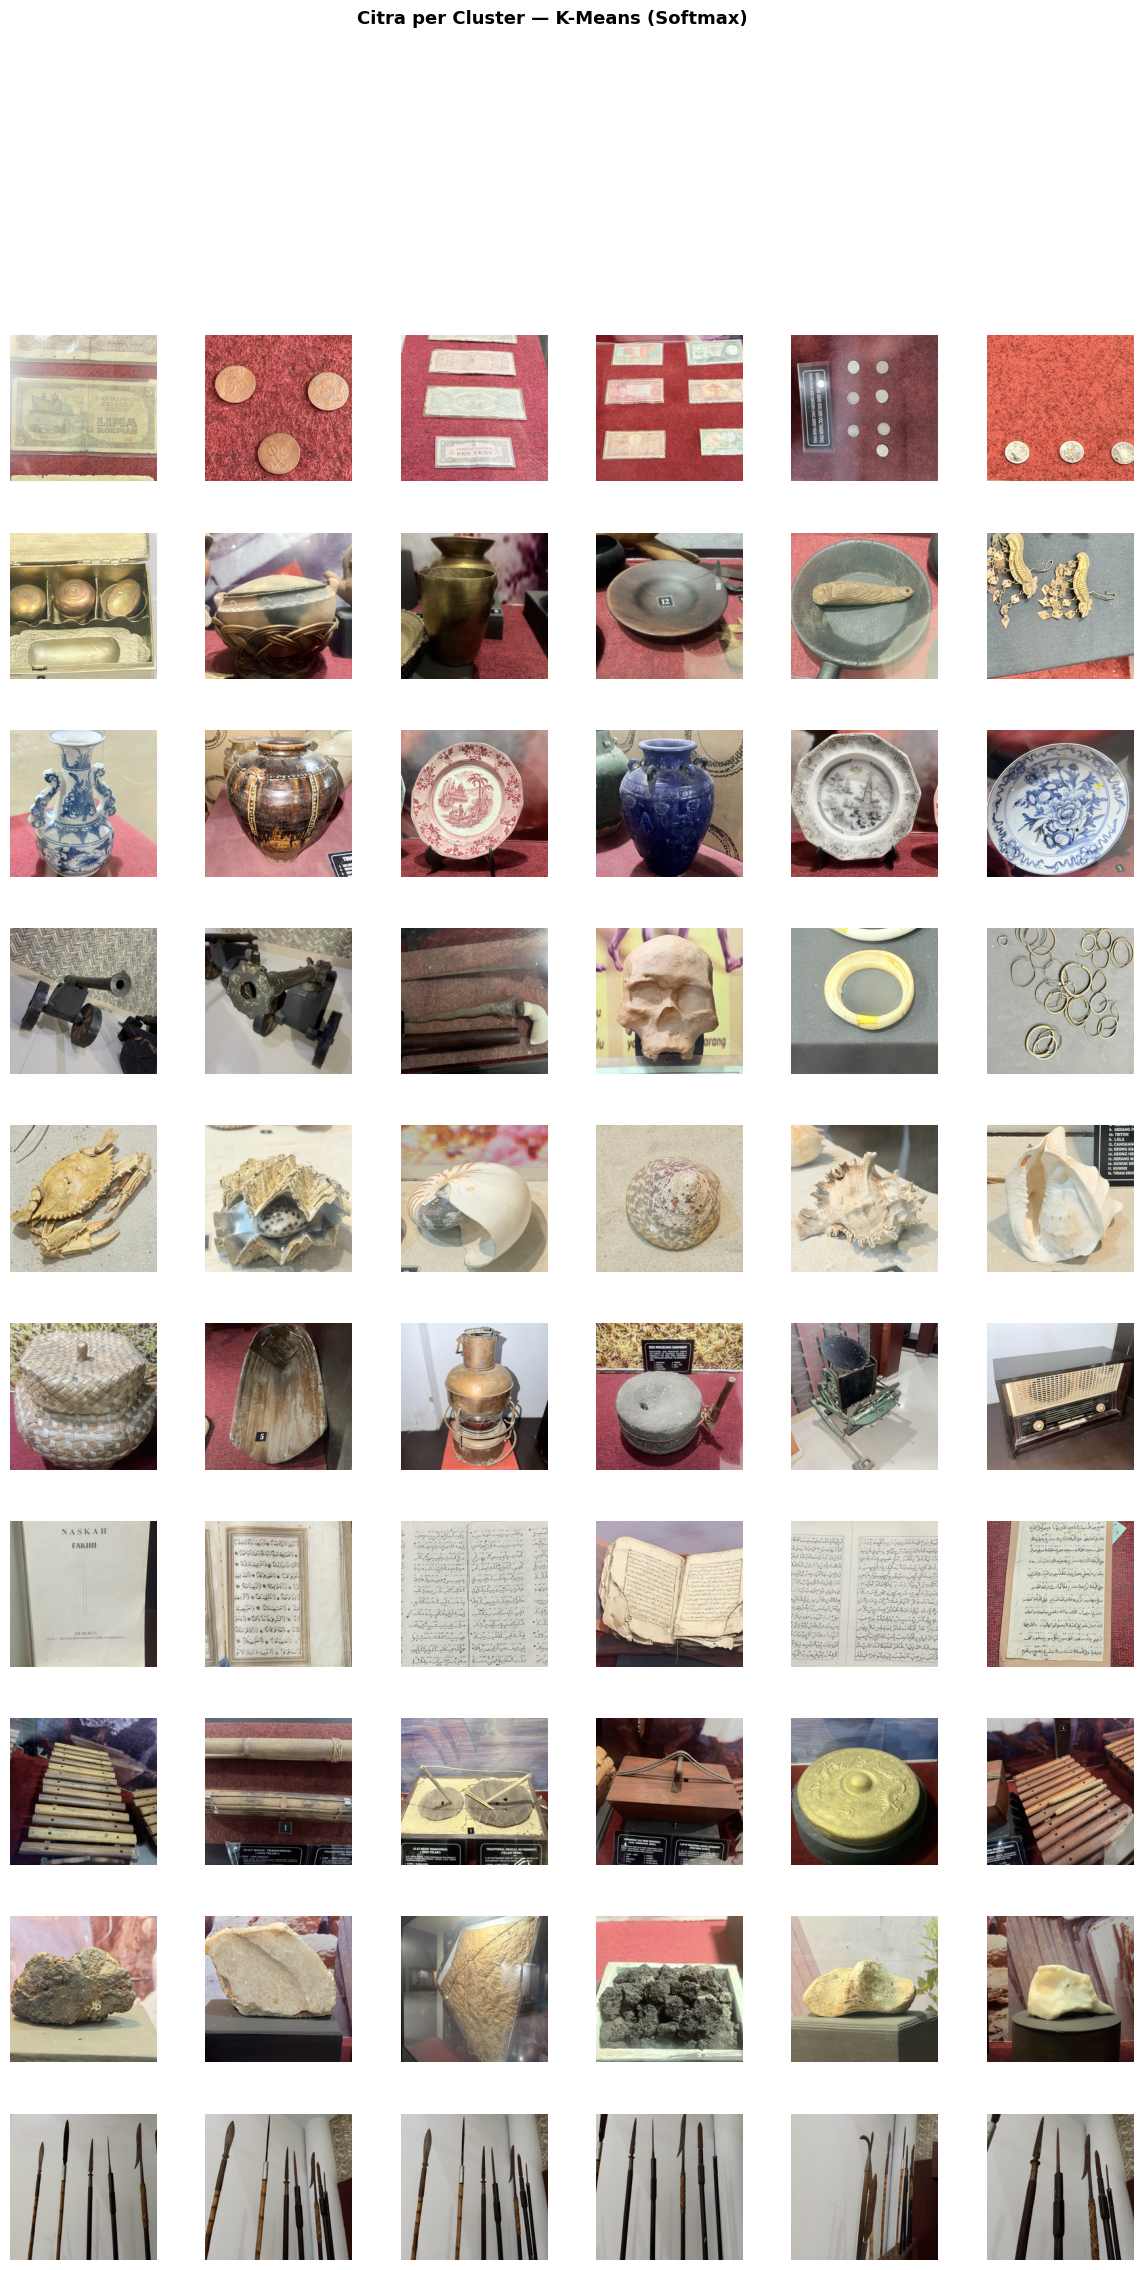

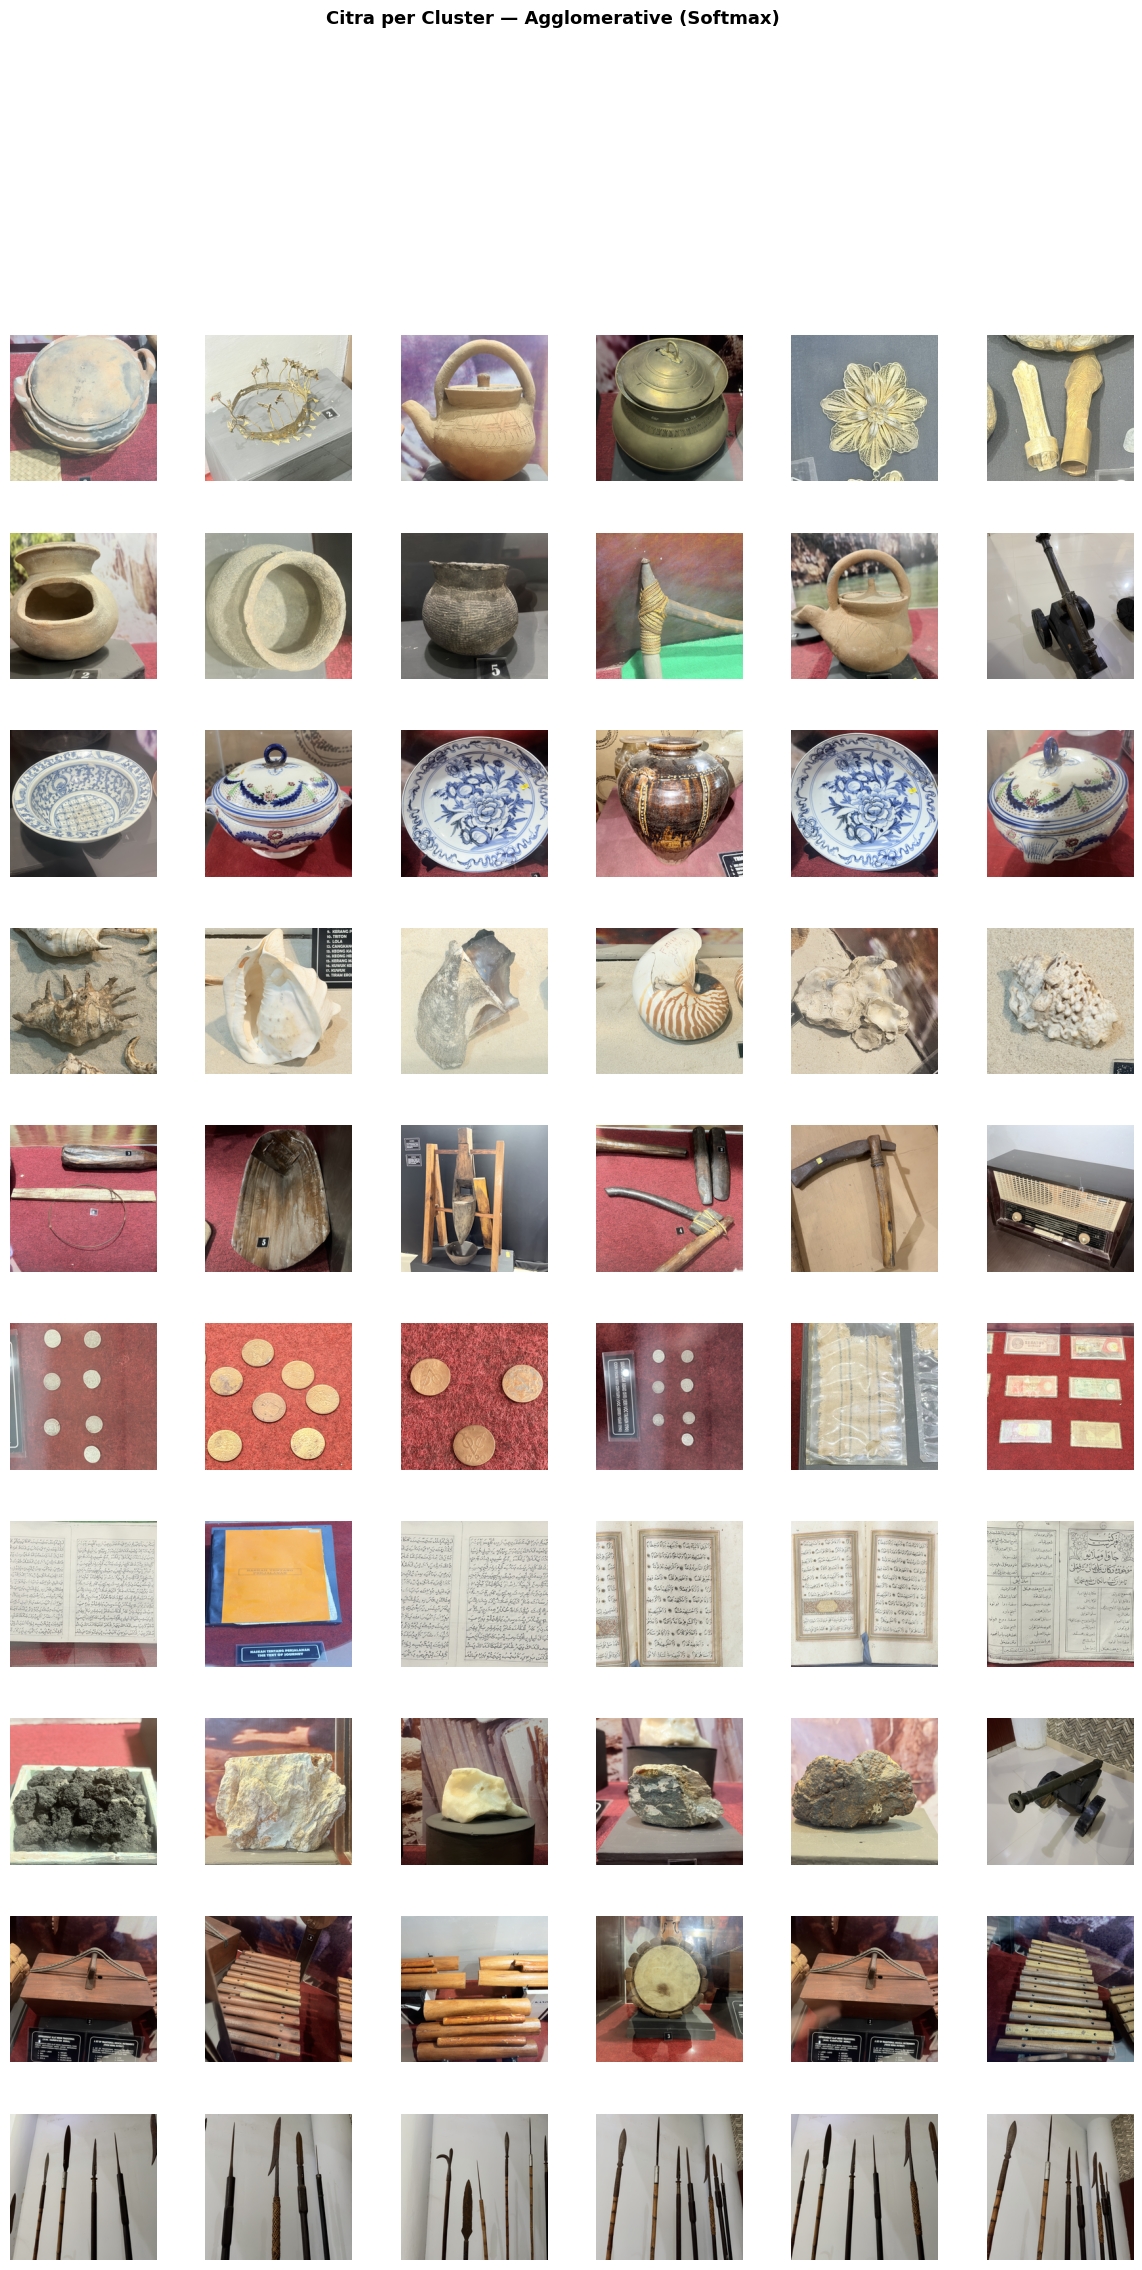

In [15]:
def plot_samples(imgs, labels, name_map, n_clusters, n_sample=6, title='', save_path=None):
    valid_cls = [cl for cl in range(n_clusters) if np.any(labels==cl)]
    fig = plt.figure(figsize=(n_sample*2.5, len(valid_cls)*2.5))
    gs  = gridspec.GridSpec(len(valid_cls), n_sample, figure=fig, hspace=0.35, wspace=0.05)
    cmap_fn = plt.cm.get_cmap('tab10', len(valid_cls))
    for ri,cl in enumerate(valid_cls):
        idx_cl = np.where(labels==cl)[0]
        chosen = np.random.choice(idx_cl, min(n_sample,len(idx_cl)), replace=False)
        cat    = name_map.get(cl, f'C{cl}')
        for j,img_idx in enumerate(chosen):
            ax = fig.add_subplot(gs[ri,j])
            img_s = imgs[img_idx]
            ax.imshow(np.clip(img_s/255.0 if img_s.max()>1 else img_s, 0, 1))
            ax.axis('off')
            if j==0:
                ax.set_ylabel(f'C{cl}\n({len(idx_cl)})\n{cat}',
                              fontsize=7,rotation=0,labelpad=70,va='center',color=cmap_fn(ri))
    fig.suptitle(f'Citra per Cluster — {title}', fontsize=13, fontweight='bold', y=1.01)
    if save_path: plt.savefig(save_path,dpi=130,bbox_inches='tight')
    plt.show()

plot_samples(images,km_labels, km_names, N_CLUSTERS, CONFIG['n_sample_vis'],
    'K-Means (Softmax)', os.path.join(CONFIG['output_root'],'grafik','05_km_clusters.png'))
plot_samples(images,agg_labels,agg_names,N_CLUSTERS, CONFIG['n_sample_vis'],
    'Agglomerative (Softmax)', os.path.join(CONFIG['output_root'],'grafik','06_agg_clusters.png'))


## Cell 16 — Simpan Gambar ke Folder Cluster

In [16]:
def save_clusters(image_paths, labels, output_dir, method='kmeans', cluster_names=None):
    base_dir = os.path.join(output_dir, f'cluster_{method}')
    for cl in sorted(set(labels)):
        fn='noise' if cl==-1 else f'cluster_{cl:02d}__{(cluster_names or {}).get(cl,"?").replace(" ","_")}'
        os.makedirs(os.path.join(base_dir,fn), exist_ok=True)
    manifest=[]
    for path,lbl in tqdm(zip(image_paths,labels),total=len(image_paths),desc=f'Save {method}'):
        fname=os.path.basename(path)
        fn='noise' if lbl==-1 else f'cluster_{lbl:02d}__{(cluster_names or {}).get(int(lbl),"?").replace(" ","_")}'
        dest=os.path.join(base_dir,fn,fname)
        if os.path.exists(dest):
            b,e=os.path.splitext(fname); dest=os.path.join(base_dir,fn,f'{b}_{np.random.randint(9999)}{e}')
        shutil.copy2(path,dest)
        manifest.append({'path':path,'cluster':int(lbl),
            'category':(cluster_names or {}).get(int(lbl),'?') if lbl!=-1 else 'noise',
            'gt_folder':os.path.basename(os.path.dirname(path)),'dest':dest})
    mpath=os.path.join(output_dir,f'manifest_{method}.csv')
    with open(mpath,'w',newline='',encoding='utf-8') as f:
        w=csv.DictWriter(f,fieldnames=list(manifest[0].keys())); w.writeheader(); w.writerows(manifest)
    print(f'[{method}] {len(manifest)} gambar → {base_dir}')

save_clusters(paths_ok, km_labels,  CONFIG['output_root'], 'kmeans',       km_names)
save_clusters(paths_ok, gmm_labels, CONFIG['output_root'], 'gmm',          gmm_names)
save_clusters(paths_ok, agg_labels, CONFIG['output_root'], 'agglomerative',agg_names)


Save kmeans: 100%|██████████| 593/593 [00:01<00:00, 300.82it/s]


[kmeans] 593 gambar → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final/cluster_kmeans


Save gmm: 100%|██████████| 593/593 [00:01<00:00, 337.96it/s]


[gmm] 593 gambar → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final/cluster_gmm


Save agglomerative: 100%|██████████| 593/593 [00:01<00:00, 357.46it/s]

[agglomerative] 593 gambar → /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final/cluster_agglomerative


## Cell 17 — Ringkasan Akhir

In [17]:
print('\n'+'='*72)
print(' RINGKASAN AKHIR — FINAL CLUSTERING (SOFTMAX 10D)')
print('='*72)
print(f'Dataset        : {len(images)} gambar | {len(class_names)} kategori museum')
print(f'Backbone       : EfficientNetV2B2 (fine-tuned)')
print(f'Val Accuracy   : {best_val_acc*100:.1f}% (fine-tuning classifier)')
print(f'Feature Space  : Softmax 10D (probabilitas per kelas)')
print()
print(f'{"Metode":<18} {"Silhouette":>12} {"DBI":>8} {"CHI":>10} {"Acc(Hungarian)":>16}')
print('-'*68)
for name,sil,dbi,chi,acc in all_methods:
    chi_s = f'{chi:10.1f}' if chi else '         -'
    acc_s = f'{acc*100:14.2f}%' if acc else '             N/A'
    flag  = ' ✅' if sil>=0.85 else ''
    print(f'{name:<18} {sil:>12.4f} {dbi:>8.4f} {chi_s} {acc_s}{flag}')
print('='*68)

if HDBSCAN_OK and hdb_sil:
    n_h = len(set(hdb_labels))-(1 if -1 in hdb_labels else 0)
    n_ns= np.sum(hdb_labels==-1)
    print(f'{"HDBSCAN (auto)":<18} {hdb_sil:>12.4f} {hdb_dbi:>8.4f} {"":>10} {"N/A":>16}')
    print(f'  HDBSCAN: {n_h} cluster, {n_ns} noise')

print(f'\nMetode terbaik: {BEST_METHOD} = {BEST_SIL:.4f}')
print(f'Acc terbaik   : {BEST_ACC*100:.2f}% (Hungarian matching)')

if BEST_SIL >= 0.85:
    print(f'\n✅ TARGET 0.85 TERCAPAI! ({BEST_SIL:.4f})')
else:
    print(f'\n⚠ Best Silhouette: {BEST_SIL:.4f}')

print(f'\nOutput dir: {CONFIG["output_root"]}')
print('='*72)

# Simpan JSON
summary = {
    'backbone': 'EfficientNetV2B2 fine-tuned',
    'feature_space': 'Softmax 10D',
    'val_accuracy': float(round(best_val_acc,4)),
    'results': {
        name: {'silhouette': round(sil,4), 'dbi': round(dbi,4),
               'acc_hungarian': round(acc,4) if acc else None}
        for name,sil,dbi,_,acc in all_methods
    },
    'best': {'method': BEST_METHOD, 'silhouette': round(BEST_SIL,4),
             'accuracy': round(BEST_ACC,4)}
}
with open(os.path.join(CONFIG['output_root'],'ringkasan_final.json'),'w') as f:
    json.dump(summary, f, indent=2, ensure_ascii=False)
print('Ringkasan tersimpan!')



 RINGKASAN AKHIR — FINAL CLUSTERING (SOFTMAX 10D)
Dataset        : 593 gambar | 10 kategori museum
Backbone       : EfficientNetV2B2 (fine-tuned)
Val Accuracy   : 95.5% (fine-tuning classifier)
Feature Space  : Softmax 10D (probabilitas per kelas)

Metode               Silhouette      DBI        CHI   Acc(Hungarian)
--------------------------------------------------------------------
K-Means                  0.8822   0.2202     1828.5          97.98% ✅
GMM                      0.8822   0.2202     1828.5          97.98% ✅
Agglomerative            0.8783   0.1993     1687.6          97.64% ✅
HDBSCAN                  0.9124   0.1476          -              N/A ✅
HDBSCAN (auto)           0.9124   0.1476                         N/A
  HDBSCAN: 10 cluster, 18 noise

Metode terbaik: HDBSCAN = 0.9124
Acc terbaik   : 97.64% (Hungarian matching)

✅ TARGET 0.85 TERCAPAI! (0.9124)

Output dir: /Users/mdaffaatstsaqif/Downloads/klaster asli/hasil_final
Ringkasan tersimpan!
